# Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', message='BigQuery Storage module not found')

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

serve_fn = tf.saved_model.load('Format-Serving').signatures['serving_default']

with open('Format-Serving/assets/customer_id_vocab') as f:
    known_customers = set(int(l.strip()) for l in f)
with open('Format-Serving/assets/product_id_vocab') as f:
    known_products = set(int(l.strip()) for l in f)

from IPython.display import display, HTML

GCP_PROJECT = 'b2b-recs'
BQ_TEST = f'{GCP_PROJECT}.raw_data.ternopil_test_v4'
client = bigquery.Client(project=GCP_PROJECT)

HISTORY_LEN = 50

def pad_history(hist, max_len=HISTORY_LEN):
    """Pad/truncate purchase history to fixed length, 0-padded."""
    arr = list(hist) if hist is not None else []
    arr = arr[:max_len]
    return arr + [0] * (max_len - len(arr))

print(f'{len(known_customers):,} customers, {len(known_products):,} products in vocab')

7,124 customers, 976 products in vocab


# Accuracy 100% match Prods and Custms

In [2]:
N_SAMPLES = 500

cust_str = ', '.join(str(c) for c in known_customers)
prod_str = ', '.join(str(p) for p in known_products)

interactions = client.query(f"""
SELECT
    CAST(customer_id AS INT64) AS customer_id,
    CAST(product_id AS INT64) AS product_id,
    cust_value,
    UNIX_SECONDS(date) AS date_unix,
    days_since_last_purchase,
    cust_order_days_60d,
    cust_unique_products_60d,
    purchase_history,
    art_name
FROM `{BQ_TEST}`
WHERE customer_id IN ({cust_str})
  AND product_id IN ({prod_str})
ORDER BY RAND()
LIMIT {N_SAMPLES}
""").to_dataframe()

interactions['days_since_last_purchase'] = interactions['days_since_last_purchase'].fillna(0).astype(int)
interactions['cust_order_days_60d'] = interactions['cust_order_days_60d'].fillna(0).astype(int)
interactions['cust_unique_products_60d'] = interactions['cust_unique_products_60d'].fillna(0).astype(int)

history_padded = np.array([pad_history(h) for h in interactions['purchase_history'].values], dtype=np.int64)

print(f'{len(interactions)} interactions, {interactions["customer_id"].nunique()} customers, {interactions["product_id"].nunique()} products')

result = serve_fn(
    customer_id=tf.constant(interactions['customer_id'].values, dtype=tf.int64),
    date=tf.constant(interactions['date_unix'].values, dtype=tf.int64),
    cust_value=tf.constant(interactions['cust_value'].values, dtype=tf.float32),
    cs_last_purch=tf.constant(interactions['days_since_last_purchase'].values, dtype=tf.int64),
    cs_orders=tf.constant(interactions['cust_order_days_60d'].values, dtype=tf.int64),
    cs_unique_skus=tf.constant(interactions['cust_unique_products_60d'].values, dtype=tf.int64),
    history=tf.constant(history_padded, dtype=tf.int64),
)

all_rec_ids = result['product_ids'].numpy()
all_rec_scores = result['scores'].numpy()

Ks = [5, 10, 50, 100, 150]

records = []
for i in range(len(interactions)):
    actual_pid = int(interactions.iloc[i]['product_id'])
    recs = all_rec_ids[i]
    row = {'customer_id': interactions.iloc[i]['customer_id'], 'product_id': actual_pid}
    for k in Ks:
        row[f'R@{k}'] = 1.0 if actual_pid in set(int(r) for r in recs[:k]) else 0.0
    records.append(row)

metrics_df = pd.DataFrame(records)

print(f'Per-interaction Recall ({len(metrics_df)} samples)')
for k in Ks:
    col = f'R@{k}'
    print(f'  {col}: {metrics_df[col].mean():.4f}  ({int(metrics_df[col].sum())}/{len(metrics_df)} hits)')

print(f'\nTraining reported: R@5=0.412, R@10=0.527, R@50=0.787, R@100=0.876')

500 interactions, 158 customers, 284 products
Per-interaction Recall (500 samples)
  R@5: 0.1660  (83/500 hits)
  R@10: 0.2100  (105/500 hits)
  R@50: 0.3520  (176/500 hits)
  R@100: 0.4640  (232/500 hits)
  R@150: 0.5160  (258/500 hits)

Training reported: R@5=0.412, R@10=0.527, R@50=0.787, R@100=0.876


# Accuracy ALL Custms, only known Prods

In [3]:
N_SAMPLES_PROD = 500

prod_str = ', '.join(str(p) for p in known_products)

# All customers, only products in vocab
prod_interactions = client.query(f"""
SELECT
    CAST(customer_id AS INT64) AS customer_id,
    CAST(product_id AS INT64) AS product_id,
    cust_value,
    UNIX_SECONDS(date) AS date_unix,
    days_since_last_purchase,
    cust_order_days_60d,
    cust_unique_products_60d,
    purchase_history,
    art_name
FROM `{BQ_TEST}`
WHERE product_id IN ({prod_str})
ORDER BY RAND()
LIMIT {N_SAMPLES_PROD}
""").to_dataframe()

prod_interactions['days_since_last_purchase'] = prod_interactions['days_since_last_purchase'].fillna(0).astype(int)
prod_interactions['cust_order_days_60d'] = prod_interactions['cust_order_days_60d'].fillna(0).astype(int)
prod_interactions['cust_unique_products_60d'] = prod_interactions['cust_unique_products_60d'].fillna(0).astype(int)

history_padded_prod = np.array([pad_history(h) for h in prod_interactions['purchase_history'].values], dtype=np.int64)

n_known_cust = prod_interactions['customer_id'].isin(known_customers).sum()
print(f'{len(prod_interactions)} interactions, '
      f'{prod_interactions["customer_id"].nunique()} customers ({n_known_cust} in vocab), '
      f'{prod_interactions["product_id"].nunique()} products (all in vocab)')

result_prod = serve_fn(
    customer_id=tf.constant(prod_interactions['customer_id'].values, dtype=tf.int64),
    date=tf.constant(prod_interactions['date_unix'].values, dtype=tf.int64),
    cust_value=tf.constant(prod_interactions['cust_value'].values, dtype=tf.float32),
    cs_last_purch=tf.constant(prod_interactions['days_since_last_purchase'].values, dtype=tf.int64),
    cs_orders=tf.constant(prod_interactions['cust_order_days_60d'].values, dtype=tf.int64),
    cs_unique_skus=tf.constant(prod_interactions['cust_unique_products_60d'].values, dtype=tf.int64),
    history=tf.constant(history_padded_prod, dtype=tf.int64),
)

rec_ids_prod = result_prod['product_ids'].numpy()

Ks = [5, 10, 50, 100, 150]

records_prod = []
for i in range(len(prod_interactions)):
    actual_pid = int(prod_interactions.iloc[i]['product_id'])
    recs = rec_ids_prod[i]
    row = {'customer_id': prod_interactions.iloc[i]['customer_id'], 'product_id': actual_pid}
    for k in Ks:
        row[f'R@{k}'] = 1.0 if actual_pid in set(int(r) for r in recs[:k]) else 0.0
    records_prod.append(row)

metrics_prod_df = pd.DataFrame(records_prod)

print(f'\nPer-interaction Recall ({len(metrics_prod_df)} samples, all customers + known products)')
for k in Ks:
    col = f'R@{k}'
    print(f'  {col}: {metrics_prod_df[col].mean():.4f}  ({int(metrics_prod_df[col].sum())}/{len(metrics_prod_df)} hits)')

print(f'\nTraining reported: R@5=0.412, R@10=0.527, R@50=0.787, R@100=0.876')

500 interactions, 190 customers (375 in vocab), 291 products (all in vocab)

Per-interaction Recall (500 samples, all customers + known products)
  R@5: 0.1280  (64/500 hits)
  R@10: 0.1700  (85/500 hits)
  R@50: 0.2880  (144/500 hits)
  R@100: 0.3880  (194/500 hits)
  R@150: 0.4380  (219/500 hits)

Training reported: R@5=0.412, R@10=0.527, R@50=0.787, R@100=0.876


# Inference vs Training Accuracy Comparison

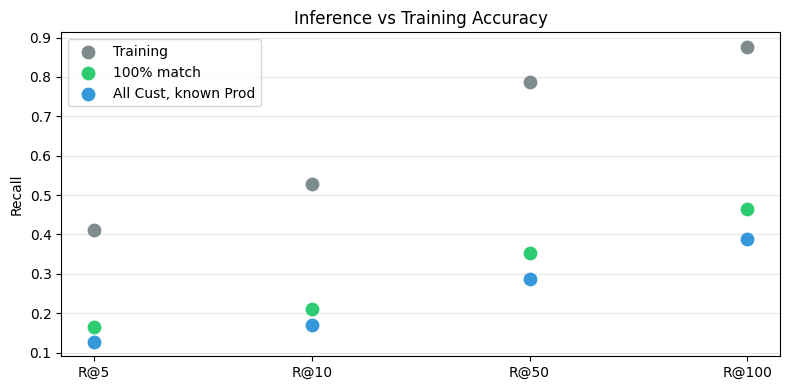

In [4]:
training_recall = {'R@5': 0.412, 'R@10': 0.527, 'R@50': 0.787, 'R@100': 0.876}
Ks = [5, 10, 50, 100]
labels = [f'R@{k}' for k in Ks]
x = np.arange(len(labels))

sources = [
    ('Training',             [training_recall[l] for l in labels], '#7f8c8d'),
    ('100% match',           [metrics_df[l].mean() for l in labels], '#2ecc71'),
    ('All Cust, known Prod', [metrics_prod_df[l].mean() for l in labels], '#3498db'),
]

fig, ax = plt.subplots(figsize=(8, 4))
for name, vals, color in sources:
    ax.scatter(x, vals, label=name, color=color, s=80, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Recall')
ax.set_title('Inference vs Training Accuracy')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Daily Basket Coverage

Known Custms & Prods: 472 interactions, 100 baskets, 100 customers
All Custms, known Prods: 460 interactions, 100 baskets, 100 customers

Known Custms & Prods — basket sizes: min=1, median=4, max=13
  R@5 coverage: mean=0.0998
  R@10 coverage: mean=0.1555
  R@50 coverage: mean=0.2698
  R@100 coverage: mean=0.3908
  R@150 coverage: mean=0.4466

All Custms, known Prods — basket sizes: min=1, median=3, max=20
  R@5 coverage: mean=0.1035
  R@10 coverage: mean=0.1438
  R@50 coverage: mean=0.2373
  R@100 coverage: mean=0.3441
  R@150 coverage: mean=0.3718


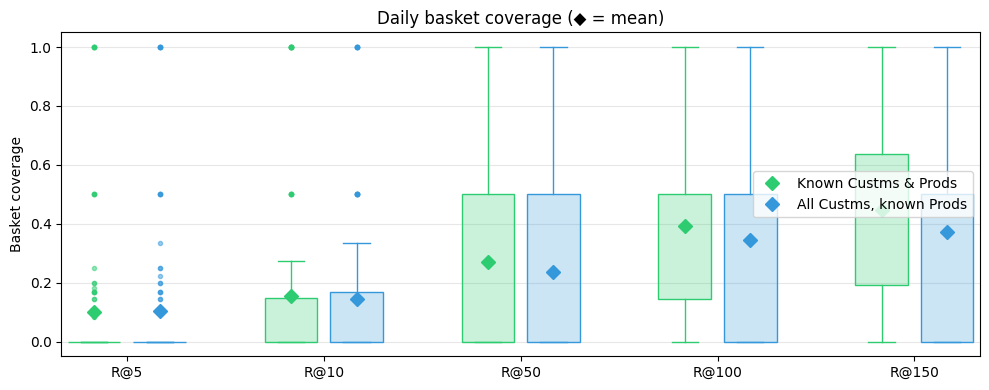

In [5]:
N_BASKET_CUSTS = 100
Ks = [5, 10, 50, 100, 150]

prod_str_b = ', '.join(str(p) for p in known_products)
cust_str_b = ', '.join(str(c) for c in known_customers)

def fetch_baskets(customer_filter):
    """Fetch and compute basket coverage. customer_filter is a SQL WHERE clause fragment."""
    raw = client.query(f"""
    WITH eligible_customers AS (
        SELECT CAST(customer_id AS INT64) AS customer_id
        FROM `{BQ_TEST}`
        WHERE {customer_filter}
          AND product_id IN ({prod_str_b})
        GROUP BY customer_id
        ORDER BY RAND()
        LIMIT {N_BASKET_CUSTS}
    )
    SELECT
        CAST(t.customer_id AS INT64) AS customer_id,
        CAST(t.product_id AS INT64) AS product_id,
        t.cust_value,
        UNIX_SECONDS(t.date) AS date_unix,
        DATE(t.date) AS purchase_date,
        t.days_since_last_purchase,
        t.cust_order_days_60d,
        t.cust_unique_products_60d,
        t.purchase_history
    FROM `{BQ_TEST}` t
    JOIN eligible_customers e ON CAST(t.customer_id AS INT64) = e.customer_id
    WHERE t.product_id IN ({prod_str_b})
    """).to_dataframe()
    raw['days_since_last_purchase'] = raw['days_since_last_purchase'].fillna(0).astype(int)
    raw['cust_order_days_60d'] = raw['cust_order_days_60d'].fillna(0).astype(int)
    raw['cust_unique_products_60d'] = raw['cust_unique_products_60d'].fillna(0).astype(int)
    raw = raw.sort_values(['customer_id', 'purchase_date']).reset_index(drop=True)

    grouped = raw.groupby(['customer_id', 'purchase_date'])
    first_rows = raw.loc[grouped.cumcount() == 0].reset_index(drop=True)

    history_padded_b = np.array([pad_history(h) for h in first_rows['purchase_history'].values], dtype=np.int64)

    res = serve_fn(
        customer_id=tf.constant(first_rows['customer_id'].values, dtype=tf.int64),
        date=tf.constant(first_rows['date_unix'].values, dtype=tf.int64),
        cust_value=tf.constant(first_rows['cust_value'].values, dtype=tf.float32),
        cs_last_purch=tf.constant(first_rows['days_since_last_purchase'].values, dtype=tf.int64),
        cs_orders=tf.constant(first_rows['cust_order_days_60d'].values, dtype=tf.int64),
        cs_unique_skus=tf.constant(first_rows['cust_unique_products_60d'].values, dtype=tf.int64),
        history=tf.constant(history_padded_b, dtype=tf.int64),
    )
    rec_ids = res['product_ids'].numpy()

    records = []
    for idx, ((cid, pdate), grp) in enumerate(grouped):
        basket_pids = set(grp['product_id'].values)
        recs = rec_ids[idx]
        row = {'customer_id': cid, 'date': pdate, 'basket_size': len(basket_pids)}
        for k in Ks:
            top_k = set(int(r) for r in recs[:k])
            row[f'R@{k}'] = len(basket_pids & top_k) / len(basket_pids)
        records.append(row)
    return pd.DataFrame(records), raw

# Known customers & known products
basket_known, raw_known = fetch_baskets(f'customer_id IN ({cust_str_b})')
print(f'Known Custms & Prods: {len(raw_known)} interactions, {len(basket_known)} baskets, '
      f'{raw_known["customer_id"].nunique()} customers')

# All customers, known products
basket_all, raw_all = fetch_baskets('TRUE')
print(f'All Custms, known Prods: {len(raw_all)} interactions, {len(basket_all)} baskets, '
      f'{raw_all["customer_id"].nunique()} customers')

for label, df in [('Known Custms & Prods', basket_known), ('All Custms, known Prods', basket_all)]:
    print(f'\n{label} — basket sizes: min={df["basket_size"].min()}, median={df["basket_size"].median():.0f}, max={df["basket_size"].max()}')
    for k in Ks:
        col = f'R@{k}'
        print(f'  {col} coverage: mean={df[col].mean():.4f}')

# Chart: side-by-side boxplots with mean as diamond marker
labels = [f'R@{k}' for k in Ks]
n = len(labels)
positions_known = np.arange(n) * 3
positions_all = positions_known + 1

fig, ax = plt.subplots(figsize=(10, 4))

bp1 = ax.boxplot([basket_known[l] for l in labels], positions=positions_known, widths=0.8,
                  showmeans=True, meanline=False,
                  meanprops=dict(marker='D', markerfacecolor='#2ecc71', markeredgecolor='#2ecc71', markersize=7),
                  flierprops=dict(marker='o', markerfacecolor='#2ecc71', markeredgecolor='#2ecc71', markersize=3, alpha=0.5),
                  medianprops=dict(linewidth=0),
                  boxprops=dict(color='#2ecc71'), whiskerprops=dict(color='#2ecc71'), capprops=dict(color='#2ecc71'),
                  patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('#2ecc7140')

bp2 = ax.boxplot([basket_all[l] for l in labels], positions=positions_all, widths=0.8,
                  showmeans=True, meanline=False,
                  meanprops=dict(marker='D', markerfacecolor='#3498db', markeredgecolor='#3498db', markersize=7),
                  flierprops=dict(marker='o', markerfacecolor='#3498db', markeredgecolor='#3498db', markersize=3, alpha=0.5),
                  medianprops=dict(linewidth=0),
                  boxprops=dict(color='#3498db'), whiskerprops=dict(color='#3498db'), capprops=dict(color='#3498db'),
                  patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('#3498db40')

ax.set_xticks(positions_known + 0.5)
ax.set_xticklabels(labels)
ax.set_ylabel('Basket coverage')
ax.set_title('Daily basket coverage (\u25c6 = mean)')
ax.legend([bp1['means'][0], bp2['means'][0]], ['Known Custms & Prods', 'All Custms, known Prods'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Customer Basket vs Model Recommendations (re-run for a new customer)

In [10]:
from IPython.display import display, HTML

BQ_TRAIN = f'{GCP_PROJECT}.raw_data.ternopil_train_v4'
cust_str_v = ', '.join(str(c) for c in known_customers)
prod_str_v = ', '.join(str(p) for p in known_products)

# Pick a random customer who has 3+ distinct products on one day
sample = client.query(f"""
WITH daily AS (
    SELECT CAST(customer_id AS INT64) AS customer_id, DATE(date) AS d,
           COUNT(DISTINCT product_id) AS n
    FROM `{BQ_TEST}`
    WHERE customer_id IN ({cust_str_v}) AND product_id IN ({prod_str_v})
    GROUP BY 1, 2
    HAVING n >= 3
)
SELECT customer_id, d FROM daily ORDER BY RAND() LIMIT 1
""").to_dataframe().iloc[0]

cid_v, day_v = int(sample['customer_id']), sample['d']

# Fetch what the customer actually bought that day (deduplicated)
bought = client.query(f"""
SELECT CAST(product_id AS INT64) AS product_id,
       ANY_VALUE(art_name) AS art_name,
       ANY_VALUE(stratbuy_domain_desc) AS category,
       ANY_VALUE(mge_main_cat_desc) AS sub_category,
       ANY_VALUE(cust_value) AS cust_value,
       ANY_VALUE(UNIX_SECONDS(date)) AS date_unix,
       ANY_VALUE(days_since_last_purchase) AS days_since_last_purchase,
       ANY_VALUE(cust_order_days_60d) AS cust_order_days_60d,
       ANY_VALUE(cust_unique_products_60d) AS cust_unique_products_60d,
       ANY_VALUE(purchase_history) AS purchase_history
FROM `{BQ_TEST}`
WHERE CAST(customer_id AS INT64) = {cid_v}
  AND DATE(date) = '{day_v}'
  AND product_id IN ({prod_str_v})
GROUP BY 1
""").to_dataframe()
bought['days_since_last_purchase'] = bought['days_since_last_purchase'].fillna(0).astype(int)
bought['cust_order_days_60d'] = bought['cust_order_days_60d'].fillna(0).astype(int)
bought['cust_unique_products_60d'] = bought['cust_unique_products_60d'].fillna(0).astype(int)

# Run inference for this customer
row0 = bought.iloc[0]
history_v = np.array([pad_history(row0['purchase_history'])], dtype=np.int64)

res_v = serve_fn(
    customer_id=tf.constant([cid_v], dtype=tf.int64),
    date=tf.constant([int(row0['date_unix'])], dtype=tf.int64),
    cust_value=tf.constant([float(row0['cust_value'])], dtype=tf.float32),
    cs_last_purch=tf.constant([int(row0['days_since_last_purchase'])], dtype=tf.int64),
    cs_orders=tf.constant([int(row0['cust_order_days_60d'])], dtype=tf.int64),
    cs_unique_skus=tf.constant([int(row0['cust_unique_products_60d'])], dtype=tf.int64),
    history=tf.constant(history_v, dtype=tf.int64),
)
rec_pids = [int(p) for p in res_v['product_ids'].numpy()[0][:150]]
rec_scores = res_v['scores'].numpy()[0][:150]

# Enrich product names + categories: test first, then fill gaps from train
rec_str = ', '.join(str(p) for p in rec_pids)
rec_meta = client.query(f"""
SELECT DISTINCT CAST(product_id AS INT64) AS product_id, art_name,
       stratbuy_domain_desc AS category, mge_main_cat_desc AS sub_category
FROM `{BQ_TEST}` WHERE product_id IN ({rec_str})
""").to_dataframe().set_index('product_id').to_dict('index')

missing = [p for p in rec_pids if p not in rec_meta]
if missing:
    miss_str = ', '.join(str(p) for p in missing)
    train_meta = client.query(f"""
    SELECT DISTINCT CAST(product_id AS INT64) AS product_id, art_name,
           stratbuy_domain_desc AS category, mge_main_cat_desc AS sub_category
    FROM `{BQ_TRAIN}` WHERE product_id IN ({miss_str})
    """).to_dataframe().set_index('product_id').to_dict('index')
    rec_meta.update(train_meta)

bought_pids = set(bought['product_id'].values)
overlap = bought_pids & set(rec_pids)

# Customer info
display(HTML(f"""
<h3>Customer {cid_v} — {day_v} — cust_value {row0['cust_value']:.0f}</h3>
<p>Bought <b>{len(bought_pids)}</b> products &nbsp;|&nbsp;
   Top-150 recs overlap: <b>{len(overlap)}</b> ({len(overlap)/len(bought_pids)*100:.0f}%)</p>
"""))

# Styles
s = 'padding:4px 10px; border:1px solid #ccc;'
hs = f'{s} background:#eee;'
hit = f'{s} background:#d4edda;'

# Table 1: What the customer bought
bought_rows = ''
for _, r in bought.iterrows():
    pid = int(r['product_id'])
    rs = hit if pid in overlap else s
    bought_rows += (f'<tr><td style="{rs}">{r["art_name"]}</td>'
                    f'<td style="{rs}">{r["category"]}</td>'
                    f'<td style="{rs}">{r["sub_category"]}</td></tr>')

display(HTML(f"""
<b>Purchased ({len(bought_pids)} products)</b>
<table style="border-collapse:collapse; font-size:13px;">
<tr><th style="{hs}">Product</th><th style="{hs}">Category</th><th style="{hs}">Sub-category</th></tr>
{bought_rows}
</table>
"""))

# Table 2: Top-150 model recommendations
rec_rows = ''
for i, pid in enumerate(rec_pids):
    m = rec_meta.get(pid, {})
    name = m.get('art_name', f'({pid})')
    cat = m.get('category', '?')
    sub = m.get('sub_category', '?')
    rs = hit if pid in bought_pids else s
    rec_rows += (f'<tr><td style="{rs}">{i+1}</td><td style="{rs}">{name}</td>'
                 f'<td style="{rs}">{cat}</td><td style="{rs}">{sub}</td>'
                 f'<td style="{rs}">{rec_scores[i]:.2f}</td></tr>')

display(HTML(f"""
<b>Model Top-150 Recommendations</b>
<table style="border-collapse:collapse; font-size:13px;">
<tr><th style="{hs}">#</th><th style="{hs}">Product</th><th style="{hs}">Category</th><th style="{hs}">Sub-category</th><th style="{hs}">Score</th></tr>
{rec_rows}
</table>
"""))

Product,Category,Sub-category
MC АНАНАС,FRUITS & VEGETABLES,ФРУКТИ
LA BARRICA ХАМОН РЕЗЕРВА 90Г,PROCESSED MEATS,СИРОКОПЧЕНА ШИНКА/М'ЯСО
MPRO ПАКЕТ МАЛ 51МКМ 40*60,DISPOSABLES & TABLEWARE,СУМКИ ДЛЯ ПОКУПОК


#,Product,Category,Sub-category,Score
1,"RIOBA МОЛОКО 2,5% UHT БЕЗЛ 950Г",DAIRY,МОЛОКО,377.24
2,MC СМЕТАНА 20% 1КГ,DAIRY,ВЕРШКИ,375.89
3,"RIOBA МОЛОКО 2,5% UHT 950Г",DAIRY,МОЛОКО,375.61
4,WHISKAS ПАУЧ ЛОСОСЬ СОУС 85Г,CANNED GOODS,КОРМ ДЛЯ ТВАРИН,374.27
5,MC ЯЙЦЕ КУРЯЧЕ С0 18,DAIRY,ЯЙЦЯ,373.29
6,MPRO ПАКЕТ ВЕЛ 51МКМ 45*74,DISPOSABLES & TABLEWARE,СУМКИ ДЛЯ ПОКУПОК,373.00
7,DISAS ІКРА ФОРЕЛІ 400Г,FRESH FISH,РИБНІ ДЕЛІКАТЕСИ,372.93
8,"МC КАБАНОСИ КУР. 250Г,В/К",PROCESSED MEATS,КОВБАСИ,371.37
9,"MC КОВБ.БРАУНШВ. С/К,В/С 350Г",PROCESSED MEATS,КОВБАСИ,371.14
10,MC СИР БРІ 60% 500Г,DAIRY,М'ЯКИЙ ЗРІЛИЙ СИР,370.50
